In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [45]:

plans = pd.read_csv('data/plans.csv')
users = pd.read_csv('data/users_latam.csv')
usage = pd.read_csv('data/usage.csv')

In [46]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [47]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [48]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [49]:

print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [50]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [51]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [52]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [53]:

print(users.isna().sum())
print(users.mean(numeric_only=True))

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id    11999.50000
age           33.73975
dtype: float64


In [54]:
print(usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


Diagnóstico de valores faltantes

El análisis de valores nulos identificó los siguientes casos:

Users – city: 469 valores faltantes de 4,000 registros (≈11.7%). Dado que la proporción es moderada, se conservarán los registros y se evaluará el uso de una categoría como Unknown para evitar perder información de otros campos.
Usage – date: 50 valores faltantes (≈1%). Al representar una proporción muy pequeña del dataset, estos registros pueden tratarse sin afectar significativamente el análisis.
Usage – duration y length: presentan una cantidad considerable de valores faltantes. Antes de imputarlos o eliminarlos, es necesario analizar su relación con el tipo de actividad (call o sms), ya que los valores ausentes podrían corresponder a características que no aplican a determinados tipos de uso.

Decisión: los valores faltantes se tratarán según su contexto y significado, evitando eliminar registros de manera automática y preservando la mayor cantidad posible de información útil.

In [55]:
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id`  solo muestra rangos normales de Id. Los quartiles solo refleja como estan numerados los usuarios.
- La columna `age` presenta un valor atípico o error (-999), posiblemente usado como marcador de datos faltantes. Esto distorsiona la media y aumenta mucho la dispersión. La mediana (47) parece representar mejor la tendencia central que la media.

In [56]:
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


Análisis de estadísticos descriptivos
id y user_id: funcionan como identificadores únicos y, por lo tanto, no aportan información estadística relevante para analizar el comportamiento de los usuarios.
duration: la media es superior a la mediana, lo que indica una distribución sesgada hacia valores altos. Se observan llamadas de hasta 120 minutos, por lo que es conveniente investigar estos valores extremos antes de realizar análisis posteriores.
length: presenta una cantidad considerable de valores faltantes y algunos valores elevados, de hasta 1,490 caracteres. Sin embargo, la media y la mediana son relativamente cercanas, lo que sugiere una distribución más estable que la observada en duration. Los valores extremos serán evaluados posteriormente para determinar si representan comportamientos reales o posibles outliers.

Conclusión: las variables duration y length requieren un análisis adicional de sus distribuciones y valores extremos antes de utilizarlas para segmentar el comportamiento de los clientes.

In [57]:

columnas_user = ['city', 'plan']
for col in columnas_user:
    print("Columna:", col)
    print(users[col].value_counts(dropna=False))
    print()

Columna: city
city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64

Columna: plan
plan
Basico     2595
Premium    1405
Name: count, dtype: int64



Análisis de variables categóricas
city: Bogotá es la ciudad con mayor número de usuarios. Se identificaron 469 valores nulos (NaN) y 96 registros con "?", lo que sugiere que "?" también representa información desconocida o faltante. Estos casos deben tratarse de manera consistente antes de realizar análisis geográficos.
plan: el plan Básico concentra la mayor cantidad de usuarios, mientras que el plan Premium tiene una participación menor. Esta diferencia será relevante posteriormente para analizar si existen distintos patrones de uso entre los clientes de cada plan.

Conclusión: antes de continuar con el análisis, es necesario estandarizar los valores faltantes de city. La distribución de plan también sugiere una oportunidad para comparar el comportamiento de los usuarios según el tipo de suscripción.

In [58]:

usage['type']
for col in usage:
    print("Columna:", col)
    print(usage[col].value_counts(dropna=False))
    print()

Columna: id
id
39984    1
39983    1
39982    1
39981    1
39980    1
        ..
5        1
4        1
3        1
2        1
1        1
Name: count, Length: 40000, dtype: int64

Columna: user_id
user_id
13819    27
13100    22
13255    22
13772    22
13475    21
         ..
11084     2
11891     2
10226     2
10660     2
12058     1
Name: count, Length: 3999, dtype: int64

Columna: type
type
text    22092
call    17908
Name: count, dtype: int64

Columna: date
date
NaN                              50
2024-04-30 15:40:27.090677266     1
2024-04-30 15:46:58.060451510     1
2024-04-30 15:53:29.030225754     1
2024-04-30 16:00:00.000000000     1
                                 ..
2024-03-01 07:53:29.030225755     1
2024-03-01 08:00:00.000000000     1
2024-03-01 08:06:30.969774244     1
2024-03-01 08:13:01.939548488     1
2024-03-01 07:14:23.211580289     1
Name: count, Length: 39951, dtype: int64

Columna: duration
duration
NaN      22076
0.21        47
0.84        43
0.02        43
0.03  

Análisis del tipo de actividad
type: se observa una mayor cantidad de mensajes de texto (text) que de llamadas (call), aunque la distribución entre ambos tipos de actividad es relativamente equilibrada.

Conclusión: ambos tipos de interacción tienen una presencia significativa en el dataset y serán considerados en el análisis del comportamiento de los clientes.


---
Validación de datos y valores faltantes
length: presenta 17,896 valores nulos. Antes de tratarlos como errores, se analizará su relación con el tipo de actividad para determinar si corresponden a valores faltantes estructurales.
id: funciona como identificador único de cada registro y no presenta inconsistencias.
user_id: contiene valores repetidos de manera esperada, ya que un mismo usuario puede generar múltiples registros de actividad. Se utilizará posteriormente para agregar la actividad a nivel de cliente.

Decisión: los valores faltantes no se eliminarán ni imputarán automáticamente hasta determinar su significado dentro de cada tipo de actividad.

In [59]:

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [60]:

usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

print("Usuarios - fechas válidas:", users['reg_date'].notna().sum())
print("Usage - fechas válidas:", usage['date'].notna().sum())


Usuarios - fechas válidas: 4000
Usage - fechas válidas: 39950


In [61]:
users_years = users['reg_date'].dt.year.value_counts().sort_index()
print("\n--- AÑOS USERS ---")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())




--- AÑOS USERS ---
reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64


Validación de fechas de registro
reg_date: se identificaron 40 registros correspondientes al año 2026 que, de acuerdo con el período esperado del dataset, se consideran fechas inválidas o posibles errores de captura.

Decisión: estos registros serán tratados como inconsistencias de calidad de datos y se corregirán o excluirán del análisis temporal según el procedimiento definido en la etapa de limpieza.

In [62]:
usage_years = usage['date'].dt.year.value_counts().sort_index()

print("\n--- AÑOS USAGE ---")
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())



--- AÑOS USAGE ---
date
2024.0    39950
NaN          50
Name: count, dtype: int64



Validación de fechas de actividad
date: se identificaron registros con fechas vacías o con formatos inválidos que no pudieron convertirse correctamente al tipo datetime.

Decisión: estos valores serán tratados como fechas faltantes (NaT) y se evaluará su impacto antes de realizar el análisis temporal.

Fechas fuera del rango esperado
users['reg_date']: se identificaron registros correspondientes a 2026, aunque el período esperado de los datos llega hasta 2024. Estas fechas se consideran inconsistentes con el contexto del dataset y pueden corresponder a errores de captura o procesamiento.
usage['date']: no se identificaron años fuera del rango esperado; sin embargo, algunas fechas no pudieron convertirse correctamente y fueron transformadas en valores faltantes (NaT).

Decisión: los registros con fechas futuras serán excluidos del análisis temporal debido a su inconsistencia con el período estudiado. Los valores NaT en usage se evaluarán y, dado que representan una proporción pequeña de los datos, podrán excluirse sin afectar significativamente los resultados.


In [63]:

age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)


users['age'].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [64]:
users['city'] = users['city'].replace("?", pd.NA)


users['city'].isna().sum()

np.int64(565)

In [65]:
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT


users['reg_date'].dt.year.value_counts(dropna=False)

,count
reg_date,
2024.0,1330
2023.0,1316
2022.0,1314
NaN,40


In [66]:
usage['duration_is_null'] = usage['duration'].isna()


print(usage.groupby('type')['duration_is_null'].mean())


type
call    0.000000
text    0.999276
Name: duration_is_null, dtype: float64


In [67]:


usage['length_is_null'] = usage['length'].isna()


print(usage.groupby('type')['length_is_null'].mean())



type
call    0.99933
text    0.00000
Name: length_is_null, dtype: float64


Análisis de valores faltantes estructurales

Se observó que los valores nulos en duration y length están directamente relacionados con la variable type:

Los registros de tipo text presentan valores nulos en duration, ya que esta variable corresponde a la duración de las llamadas.
Los registros de tipo call presentan valores nulos en length, ya que esta variable corresponde a la longitud de los mensajes de texto.

Por lo tanto, estos valores nulos se consideran estructurales y esperados según el tipo de actividad, y no errores de calidad de datos.

Decisión: no se imputarán ni eliminarán estos valores. En los análisis posteriores, duration y length se evaluarán de acuerdo con el tipo de actividad correspondiente.

In [68]:


usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)


usage_agg = (
    usage.groupby("user_id")
    .agg(
        total_calls=("is_call", "sum"),
        total_texts=("is_text", "sum"),
        total_duration=("duration", "sum"),
        total_length=("length", "sum")
    )
    .reset_index()
)

usage_agg.head(3)

,user_id,total_calls,total_texts,total_duration,total_length
0,10000,3,7,23.70,258.0
1,10001,10,5,33.18,226.0
2,10002,2,5,10.74,225.0


In [69]:
usage_agg = usage_agg.rename(columns={
    'is_text':'cant_mensajes',
    'is_call':'cant_llamadas',
    'duration':'cant_minutos_llamada'
})


usage_agg.head(3)

,user_id,total_calls,total_texts,total_duration,total_length
0,10000,3,7,23.70,258.0
1,10001,10,5,33.18,226.0
2,10002,2,5,10.74,225.0


In [70]:

user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left'
)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_calls,total_texts,total_duration,total_length
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0


In [71]:
print(user_profile[[
    'age',
    'total_texts',
    'total_calls',
    'total_duration'
]].describe())


               age  total_texts  total_calls  total_duration
count  4000.000000  3999.000000  3999.000000     3999.000000
mean     48.136000     5.524381     4.478120       23.317054
std      17.689919     2.358416     2.144238       18.168095
min      18.000000     0.000000     0.000000        0.000000
25%      33.000000     4.000000     3.000000       11.120000
50%      48.000000     5.000000     4.000000       19.780000
75%      63.000000     7.000000     6.000000       31.415000
max      79.000000    17.000000    15.000000      155.690000


In [72]:

plan_dist = (
    user_profile['plan']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print(plan_dist)


plan
Basico     64.88
Premium    35.12
Name: proportion, dtype: float64


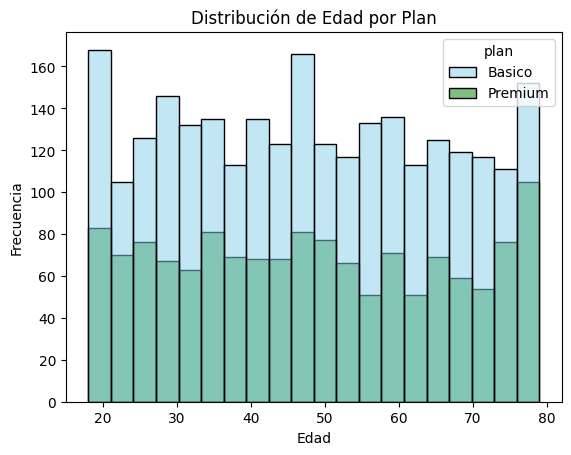

In [73]:

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue','green'],
    bins=20
)

plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

Distribución de edad por tipo de plan

Insight: no se observa una relación clara entre la edad de los usuarios y el tipo de plan contratado. Los clientes de los planes Básico y Premium presentan distribuciones de edad similares en la mayoría de los rangos analizados.

Distribución: las edades se encuentran relativamente distribuidas a lo largo de los distintos rangos, sin observarse una concentración marcada de un plan en un grupo de edad específico.

Conclusión: la edad, por sí sola, no parece ser un factor determinante en la elección entre los planes Básico y Premium.

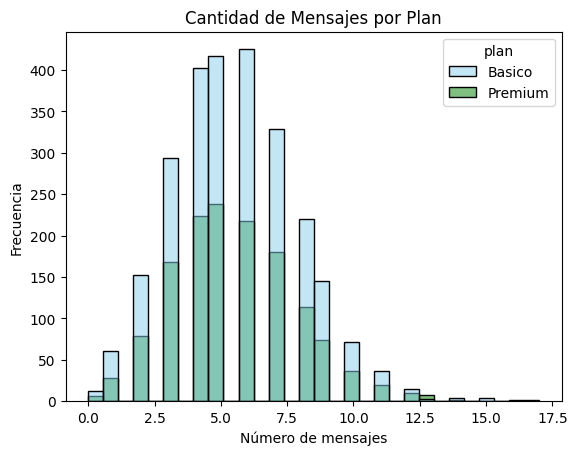

In [74]:
sns.histplot(
    data=user_profile,
    x='total_texts',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=30
)

plt.title('Cantidad de Mensajes por Plan')
plt.xlabel('Número de mensajes')
plt.ylabel('Frecuencia')
plt.show()

Distribución del uso de mensajes por plan

Insight: los usuarios de los planes Básico y Premium presentan patrones similares en el envío de mensajes. La mayor concentración se encuentra alrededor de 4 a 7 mensajes, sin observarse una proporción claramente mayor de usuarios intensivos en el plan Premium.

Distribución: se observa un sesgo hacia la derecha: la mayoría de los usuarios registra niveles bajos o moderados de mensajería, mientras que un grupo reducido presenta un número considerablemente mayor de mensajes.

Conclusión: el nivel de uso de mensajes no muestra una diferenciación clara entre los planes Básico y Premium, por lo que esta variable por sí sola no parece explicar la elección del plan.

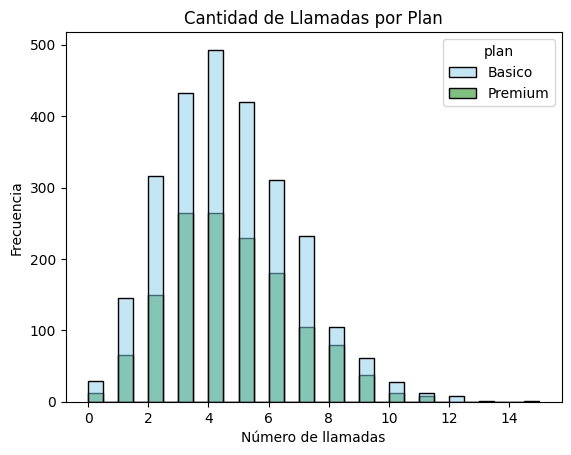

In [75]:
sns.histplot(
    data=user_profile,
    x='total_calls',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=30
)

plt.title('Cantidad de Llamadas por Plan')
plt.xlabel('Número de llamadas')
plt.ylabel('Frecuencia')
plt.show()


Distribución de llamadas por tipo de plan

Insight: los usuarios de los planes Básico y Premium presentan patrones similares en la cantidad de llamadas. La mayor concentración se encuentra entre 3 y 6 llamadas, especialmente alrededor de 4–5, sin observarse una diferencia marcada entre ambos planes.

Los usuarios con un número elevado de llamadas son poco frecuentes en ambos grupos, lo que indica que el uso intensivo de llamadas representa una proporción menor de los clientes.

Distribución: se observa un sesgo hacia la derecha: la mayoría de los usuarios realiza una cantidad baja o moderada de llamadas, mientras que un grupo reducido presenta niveles de uso considerablemente mayores.

Conclusión: al igual que con los mensajes, la cantidad de llamadas no muestra una diferenciación clara entre los clientes de los planes Básico y Premium.

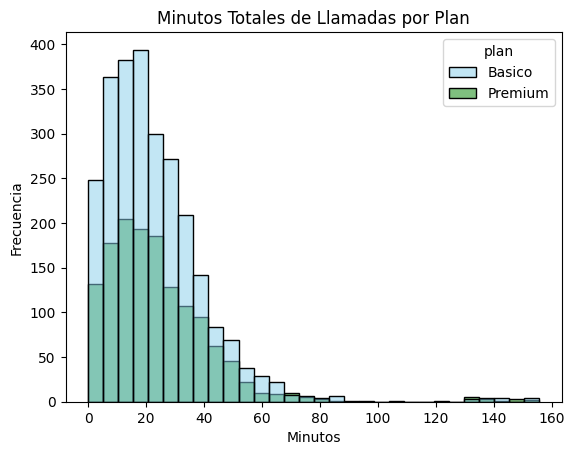

In [76]:
sns.histplot(
    data=user_profile,
    x='total_duration',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=30
)

plt.title('Minutos Totales de Llamadas por Plan')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')
plt.show()


Distribución de minutos de llamadas por plan

Insight: los usuarios del plan Básico se concentran principalmente en niveles bajos o moderados de minutos de llamada. En el plan Premium se observa una mayor presencia de usuarios con consumos elevados y una cola más extendida hacia valores altos.

Distribución: ambos planes presentan una distribución sesgada hacia la derecha. La mayoría de los usuarios acumula pocos o moderados minutos de llamadas, mientras que un grupo reducido registra un consumo considerablemente mayor.

Conclusión: aunque la cantidad de llamadas era similar entre ambos planes, el análisis de su duración total sugiere diferencias en la intensidad de uso. Algunos usuarios Premium parecen realizar llamadas más prolongadas, por lo que los minutos consumidos podrían ser una variable más útil que el número de llamadas para caracterizar el comportamiento de los clientes.

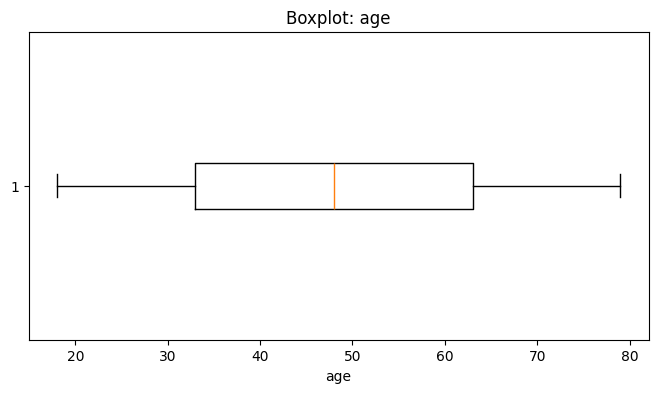

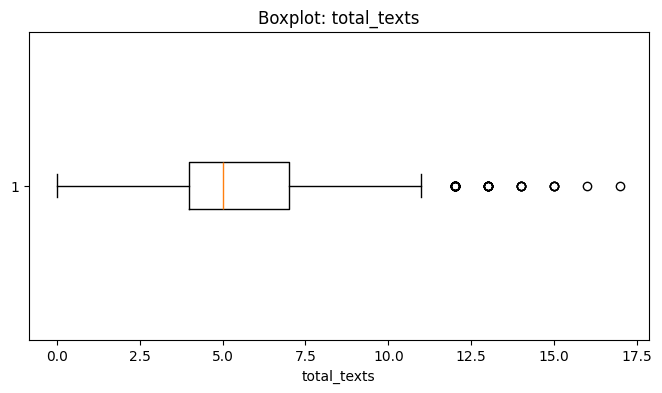

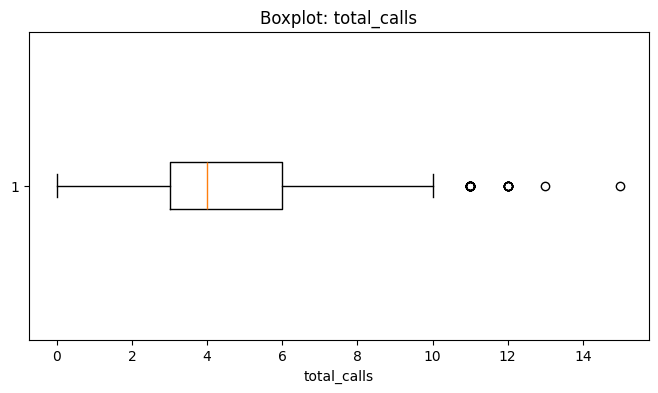

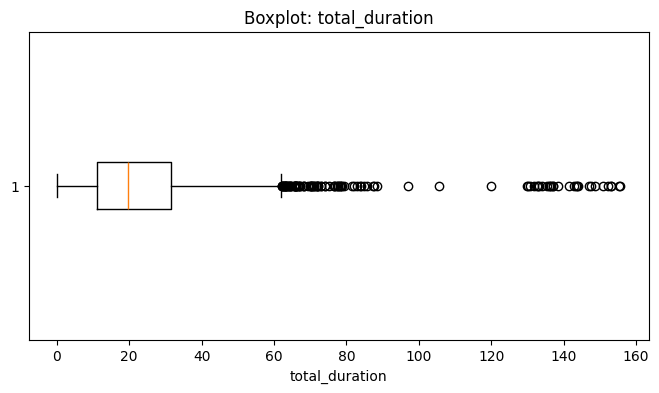

In [77]:

columnas_numericas = [
    'age',
    'total_texts',
    'total_calls',
    'total_duration'
]

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    plt.boxplot(user_profile[col].dropna(), vert=False)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

Análisis de valores atípicos
age: se observan valores atípicos que deben revisarse para determinar si corresponden a edades válidas o a posibles errores de registro.
total_texts: se identifican valores superiores al rango habitual, lo que puede representar usuarios con un nivel de mensajería significativamente mayor que el resto.
total_calls: los valores atípicos sugieren la existencia de clientes con un uso intensivo de llamadas. Estos registros se conservarán mientras representen comportamientos válidos.
total_duration: se observan valores extremos superiores asociados con usuarios que acumulan un mayor número de minutos de llamada.

Decisión: los valores atípicos no se eliminarán automáticamente. Primero se evaluará su validez y relevancia, ya que pueden representar comportamientos reales de clientes de alto consumo y aportar información importante para la segmentación.

In [78]:

columnas_limites = [
    'age',
    'total_texts',
    'total_calls',
    'total_duration'
]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR
    maximo = user_profile[col].max()

    print(f'\nVariable: {col}')
    print(f'Límite superior: {limite_superior:.2f}')
    print(f'Máximo: {maximo:.2f}')

    if maximo > limite_superior:
        print('Sí hay outliers superiores.')
    else:
        print('No hay outliers superiores.')



Variable: age
Límite superior: 108.00
Máximo: 79.00
No hay outliers superiores.

Variable: total_texts
Límite superior: 11.50
Máximo: 17.00
Sí hay outliers superiores.

Variable: total_calls
Límite superior: 10.50
Máximo: 15.00
Sí hay outliers superiores.

Variable: total_duration
Límite superior: 61.86
Máximo: 155.69
Sí hay outliers superiores.


In [79]:

user_profile[columnas_limites].describe()

,age,total_texts,total_calls,total_duration
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


Evaluación de valores atípicos mediante IQR
total_texts: aunque se identifican valores por encima del límite IQR, el máximo observado (17 mensajes) no se encuentra extremadamente alejado del tercer cuartil (Q3 = 7). Estos valores se conservarán como parte de la variabilidad natural del comportamiento de los usuarios.
total_calls: el máximo observado (15 llamadas) tampoco representa un valor desproporcionado respecto al tercer cuartil (Q3 = 6), por lo que los valores atípicos se mantendrán.
total_duration: el máximo de 155.69 minutos se encuentra considerablemente alejado del tercer cuartil (Q3 = 31.41), indicando la presencia de usuarios con un consumo de llamadas significativamente superior al habitual.

Decisión: no se eliminarán automáticamente los valores extremos de total_duration, ya que pueden representar usuarios intensivos reales. Se conservarán para el análisis de comportamiento y segmentación, evaluando su impacto en las métricas agregadas.


In [80]:

condiciones = [
    (user_profile['total_calls'] < 5) & (user_profile['total_texts'] < 5),
    (user_profile['total_calls'] < 10) & (user_profile['total_texts'] < 10)
]

valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(
    condiciones,
    valores,
    default='Alto uso'
)

In [81]:

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_calls,total_texts,total_duration,total_length,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0,Bajo uso


In [82]:

condiciones = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]


valores = ['Joven', 'Adulto']


user_profile['grupo_edad'] = np.select(condiciones, valores, default='Adulto Mayor')

In [83]:

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_calls,total_texts,total_duration,total_length,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0,Bajo uso,Adulto Mayor


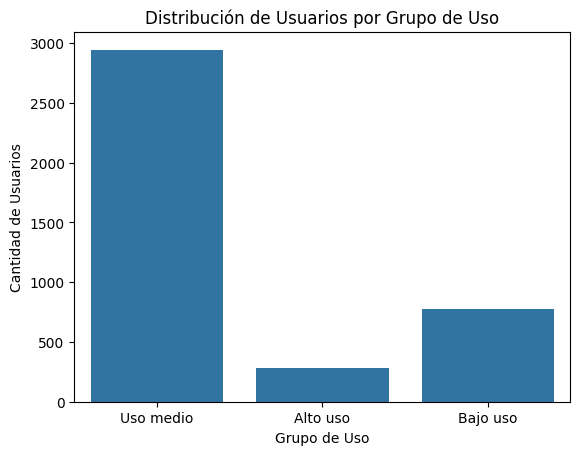

In [84]:

sns.countplot(x='grupo_uso', data=user_profile)

plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

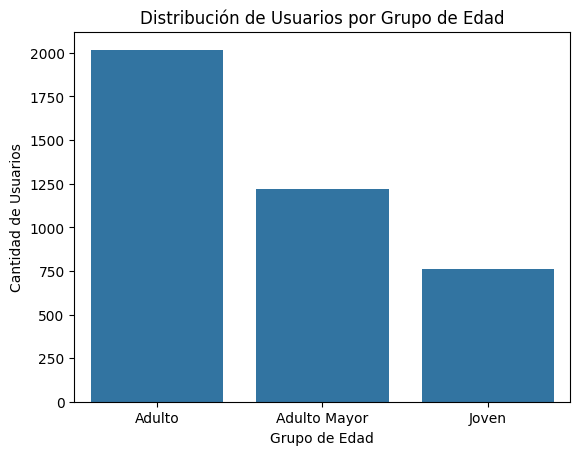

In [85]:

sns.countplot(x='grupo_edad', data=user_profile)

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()


### Análisis ejecutivo

#### Calidad de los datos

El análisis identificó algunos problemas de calidad que requirieron tratamiento antes de estudiar el comportamiento de los clientes:

* La variable `city` presenta **469 valores nulos (≈11.7%)** y 96 registros con `"?"`, lo que limita la confiabilidad de análisis geográficos.
* Se identificaron valores sentinel en `age` (`-999`), que fueron tratados durante la limpieza de datos.
* Las variables `duration` y `length` presentan valores faltantes estructurales asociados al tipo de actividad (`call` o `text`), por lo que no fueron eliminados ni imputados automáticamente.
* Se detectaron valores atípicos en las métricas de uso, especialmente en `total_duration`. Estos registros se conservaron porque pueden representar clientes con patrones reales de alto consumo.

#### Segmentación de clientes

Los usuarios fueron segmentados utilizando dos dimensiones: **edad** y **nivel de uso**.

Por nivel de uso se identificaron tres grupos:

* **Bajo uso:** menos de 5 llamadas y 5 mensajes.
* **Uso medio:** menos de 10 llamadas y 10 mensajes.
* **Alto uso:** clientes que superan estos niveles de actividad.

Esta segmentación permite identificar diferentes patrones de comportamiento sin asumir que los valores extremos representan necesariamente errores.

#### Principales insights

El análisis muestra que la **edad, la cantidad de mensajes y el número de llamadas no presentan diferencias marcadas entre los usuarios de los planes Básico y Premium**.

Sin embargo, la duración total de las llamadas muestra una diferencia más visible: algunos usuarios Premium presentan niveles de consumo superiores, lo que sugiere que la **intensidad de uso puede ser más informativa que el número de interacciones** para caracterizar a los clientes.

Los usuarios con niveles elevados de actividad representan un segmento especialmente relevante para investigar, ya que sus patrones de consumo pueden ayudar a diseñar ofertas y estrategias de retención más específicas.

### Recomendaciones de negocio

1. **Utilizar la intensidad de uso para segmentar clientes:** complementar el tipo de plan con métricas de comportamiento como minutos de llamada, número de llamadas y mensajes.

2. **Identificar oportunidades de upselling:** analizar usuarios de uso medio y alto para determinar si su comportamiento está alineado con el plan contratado y detectar posibles oportunidades de migración a planes superiores.

3. **Analizar clientes de alto consumo:** conservar y estudiar los valores extremos válidos en lugar de eliminarlos automáticamente, ya que pueden revelar perfiles de usuarios intensivos.

4. **Mejorar la calidad de los datos:** estandarizar los valores faltantes de `city`, validar las fechas y establecer controles para evitar valores sentinel o categorías inválidas.

5. **Profundizar el análisis de planes:** dado que varias métricas muestran comportamientos similares entre Básico y Premium, futuras evaluaciones podrían incorporar variables como ingresos, precio del plan, uso de datos y permanencia del cliente para determinar qué factores explican mejor la elección del plan.


